In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ttest_ind
import warnings
warnings.filterwarnings('ignore')

BASE         = 'C:/Users/Saurabh yadav/Documents/Patient Readmission Risk Analysis/'
TABLEAU_PATH = BASE + 'tableau/'
OUTPUT_PATH  = BASE + 'outputs/'

df = pd.read_csv(TABLEAU_PATH + 'clean_patients.csv')
print('Data loaded:', df.shape)
print('Readmission rate:', round(df['readmitted_binary'].mean()*100, 2), '%')

Data loaded: (71518, 17)
Readmission rate: 8.8 %


In [2]:
contingency = pd.crosstab(df['gender'], df['readmitted_binary'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print('=== TEST 1: CHI-SQUARE — GENDER vs READMISSION ===')
print()
print('Contingency Table:')
print(contingency)
print()
print(f'Chi-square statistic: {chi2:.4f}')
print(f'P-value:              {p_value:.6f}')
print(f'Degrees of freedom:   {dof}')
print()
if p_value < 0.05:
    print('RESULT: SIGNIFICANT — Gender has a statistically significant')
    print('        relationship with 30-day readmission (p < 0.05)')
else:
    print('RESULT: NOT SIGNIFICANT — No significant relationship found (p >= 0.05)')

=== TEST 1: CHI-SQUARE — GENDER vs READMISSION ===

Contingency Table:
readmitted_binary      0     1
gender                        
Female             34655  3370
Male               30567  2923
Unknown/Invalid        3     0

Chi-square statistic: 0.6915
P-value:              0.707676
Degrees of freedom:   2

RESULT: NOT SIGNIFICANT — No significant relationship found (p >= 0.05)


In [3]:
groups = [
    df[df['stay_category'] == 'Short (1-3)']['readmitted_binary'],
    df[df['stay_category'] == 'Medium (4-7)']['readmitted_binary'],
    df[df['stay_category'] == 'Long (8-14)']['readmitted_binary']
]

f_stat, p_value = f_oneway(*groups)

print('=== TEST 2: ONE-WAY ANOVA — STAY DURATION vs READMISSION ===')
print()
print('Readmission rate by stay duration:')
print(df.groupby('stay_category')['readmitted_binary'].mean().mul(100).round(2))
print()
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print()
if p_value < 0.05:
    print('RESULT: SIGNIFICANT — Hospital stay duration significantly')
    print('        affects 30-day readmission rate (p < 0.05)')
else:
    print('RESULT: NOT SIGNIFICANT (p >= 0.05)')

=== TEST 2: ONE-WAY ANOVA — STAY DURATION vs READMISSION ===

Readmission rate by stay duration:
stay_category
Long (8-14)     11.41
Medium (4-7)     9.74
Short (1-3)      7.39
Name: readmitted_binary, dtype: float64

F-statistic: 101.1969
P-value:     0.000000

RESULT: SIGNIFICANT — Hospital stay duration significantly
        affects 30-day readmission rate (p < 0.05)


In [4]:
readmitted     = df[df['readmitted_binary'] == 1]['num_medications']
not_readmitted = df[df['readmitted_binary'] == 0]['num_medications']

t_stat, p_value = ttest_ind(readmitted, not_readmitted)

print('=== TEST 3: T-TEST — MEDICATIONS vs READMISSION ===')
print()
print(f'Avg medications (readmitted):     {readmitted.mean():.2f}')
print(f'Avg medications (not readmitted): {not_readmitted.mean():.2f}')
print()
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print()
if p_value < 0.05:
    print('RESULT: SIGNIFICANT — Number of medications is significantly')
    print('        different between readmitted and non-readmitted patients')
else:
    print('RESULT: NOT SIGNIFICANT (p >= 0.05)')

=== TEST 3: T-TEST — MEDICATIONS vs READMISSION ===

Avg medications (readmitted):     16.62
Avg medications (not readmitted): 15.62

T-statistic: 9.1523
P-value:     0.000000

RESULT: SIGNIFICANT — Number of medications is significantly
        different between readmitted and non-readmitted patients


In [5]:
readmitted     = df[df['readmitted_binary'] == 1]['num_lab_procedures']
not_readmitted = df[df['readmitted_binary'] == 0]['num_lab_procedures']

t_stat, p_value = ttest_ind(readmitted, not_readmitted)

print('=== TEST 4: T-TEST — LAB PROCEDURES vs READMISSION ===')
print()
print(f'Avg lab procedures (readmitted):     {readmitted.mean():.2f}')
print(f'Avg lab procedures (not readmitted): {not_readmitted.mean():.2f}')
print()
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print()
if p_value < 0.05:
    print('RESULT: SIGNIFICANT — Lab procedures significantly differ')
    print('        between readmitted and non-readmitted patients')
else:
    print('RESULT: NOT SIGNIFICANT (p >= 0.05)')

=== TEST 4: T-TEST — LAB PROCEDURES vs READMISSION ===

Avg lab procedures (readmitted):     44.93
Avg lab procedures (not readmitted): 42.90

T-statistic: 7.7251
P-value:     0.000000

RESULT: SIGNIFICANT — Lab procedures significantly differ
        between readmitted and non-readmitted patients


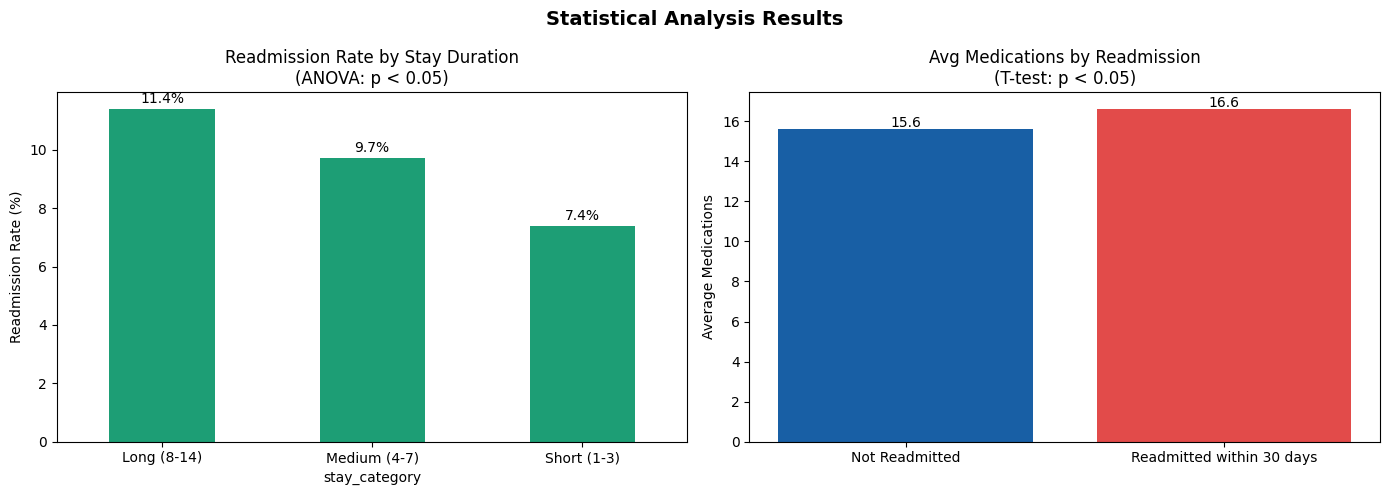

Chart 6 saved

Phase 2 Statistical Analysis Complete!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Statistical Analysis Results', fontsize=14, fontweight='bold')

stay_rates = df.groupby('stay_category')['readmitted_binary'].mean().mul(100)
stay_rates.plot(kind='bar', ax=axes[0], color='#1D9E75', edgecolor='none')
axes[0].set_title('Readmission Rate by Stay Duration\n(ANOVA: p < 0.05)')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(stay_rates):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

med_means = df.groupby('readmitted_binary')['num_medications'].mean()
bars = axes[1].bar(['Not Readmitted','Readmitted within 30 days'],
                   med_means, color=['#185FA5','#E24B4A'], edgecolor='none')
axes[1].set_title('Avg Medications by Readmission\n(T-test: p < 0.05)')
axes[1].set_ylabel('Average Medications')
for bar, val in zip(bars, med_means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1, f'{val:.1f}',
                 ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart6_statistical_results.png', bbox_inches='tight')
plt.show()
print('Chart 6 saved')
print()
print('Phase 2 Statistical Analysis Complete!')